In [1]:
# DATA ANALYSIS

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("shared_target_results.csv")

df.head()

,run_number,target_number,method,guesses
0,1,38,Linear,38
1,1,38,Reverse Linear,63
2,1,38,Random,6
3,1,38,Binary,6
4,1,38,Ternary,5


In [3]:
df.shape

(8000000, 4)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000000 entries, 0 to 7999999
Data columns (total 4 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   run_number     int64 
 1   target_number  int64 
 2   method         object
 3   guesses        int64 
dtypes: int64(3), object(1)
memory usage: 244.1+ MB


In [5]:
df.describe()

,run_number,target_number,guesses
count,8.000000e+06,8.000000e+06,8.000000e+06
mean,5.000005e+05,5.048360e+01,1.734227e+01
std,2.886752e+05,2.886828e+01,2.403201e+01
min,1.000000e+00,1.000000e+00,1.000000e+00
25%,2.500008e+05,2.500000e+01,6.000000e+00
50%,5.000005e+05,5.000000e+01,7.000000e+00
75%,7.500002e+05,7.500000e+01,1.000000e+01
max,1.000000e+06,1.000000e+02,1.000000e+02


In [7]:
mean_performance = df.groupby("method")["guesses"].mean().sort_values()
mean_performance

method
Binary             5.798505
Golden Ratio       5.890455
Step 25            6.028356
Noisy Midpoint     6.265129
Ternary            6.279017
Random             7.476681
Linear            50.483605
Reverse Linear    50.516395
Name: guesses, dtype: float64

In [8]:
df.groupby("method")["guesses"].median().sort_values()

method
Binary             6.0
Golden Ratio       6.0
Noisy Midpoint     6.0
Step 25            6.0
Ternary            6.0
Random             7.0
Linear            50.0
Reverse Linear    51.0
Name: guesses, dtype: float64

In [9]:
df.groupby("method")["guesses"].max().sort_values()

method
Binary              7
Golden Ratio        8
Step 25             8
Ternary            11
Noisy Midpoint     13
Random             22
Linear            100
Reverse Linear    100
Name: guesses, dtype: int64

In [10]:
df.groupby("method")["guesses"].std().sort_values()

method
Binary             1.319430
Golden Ratio       1.420782
Step 25            1.531687
Noisy Midpoint     1.805176
Ternary            1.810012
Random             2.683106
Linear            28.868298
Reverse Linear    28.868298
Name: guesses, dtype: float64

In [11]:
hardest_numbers = df.groupby("target_number")["guesses"].mean().sort_values(ascending=False)
hardest_numbers.head(10)

target_number
70     18.190831
100    18.083706
67     18.033453
55     17.941735
33     17.902792
79     17.856942
77     17.815522
54     17.811843
87     17.805475
30     17.790457
Name: guesses, dtype: float64

In [13]:
### Performance VS Target Number

pivot = df.pivot_table(
    index="target_number",
    columns="method",
    values="guesses",
    aggfunc="mean"
)

pivot

method,Binary,Golden Ratio,Linear,Noisy Midpoint,Random,Reverse Linear,Step 25,Ternary
target_number,,,,,,,,
1,6.0,8.0,1.0,5.964083,5.179783,100.0,5.0,4.0
2,7.0,7.0,2.0,6.521094,5.689948,99.0,6.0,5.0
3,5.0,8.0,3.0,6.552084,6.006328,98.0,4.0,6.0
4,6.0,6.0,4.0,6.529660,6.205259,97.0,5.0,3.0
5,7.0,7.0,5.0,6.474012,6.456051,96.0,6.0,5.0
...,...,...,...,...,...,...,...,...
96,7.0,5.0,96.0,6.605854,6.472058,5.0,7.0,9.0
97,5.0,6.0,97.0,6.670683,6.237104,4.0,8.0,8.0
98,7.0,4.0,98.0,6.808442,5.986521,3.0,6.0,9.0


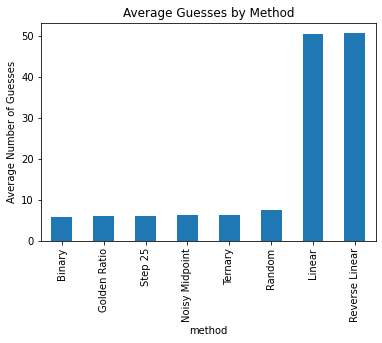

In [14]:
mean_performance.plot(kind="bar")
plt.ylabel("Average Number of Guesses")
plt.title("Average Guesses by Method")
plt.show()

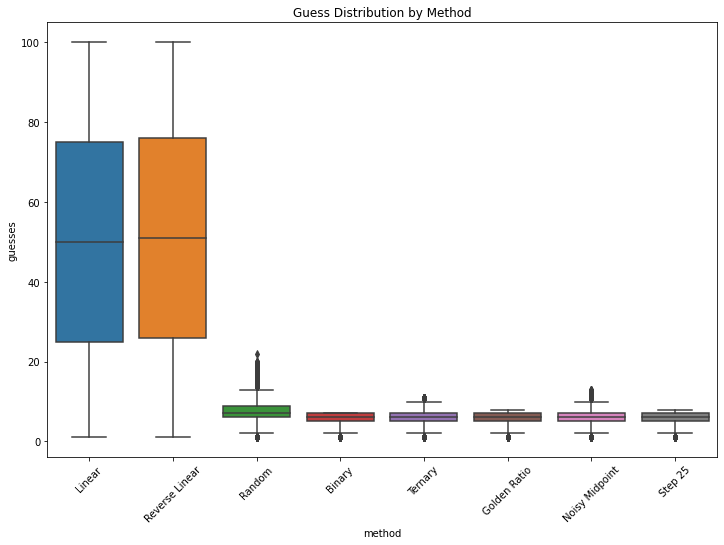

In [17]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df, x="method", y="guesses")
plt.xticks(rotation=45)
plt.title("Guess Distribution by Method")
plt.show()

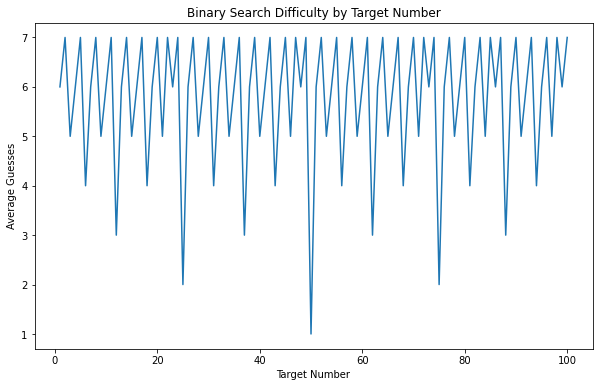

In [18]:
plt.figure(figsize=(10,6))
plt.plot(pivot.index, pivot["Binary"])
plt.xlabel("Target Number")
plt.ylabel("Average Guesses")
plt.title("Binary Search Difficulty by Target Number")
plt.show()